In [1]:
import numpy as np
from scipy.linalg import eigh 
import matplotlib.pyplot as plt

In [2]:
def lda(X,y,new_dim):
    
    # this function reduces data dimension to new_dim
    # dimension x number of points
    original_dim,n = X.shape

    # classes
    classes = np.unique(y) 
    n_classes = len(classes)

    # data points mean
    M = np.mean(X,axis=1,keepdims=True)

    # class sizes, means, between-class scatter matrix S_B, within-class scatt er matrix S_W
    class_size = np.zeros(len(classes))
    class_mean = np.zeros((original_dim,len(classes))) 
    SB = np.zeros((original_dim,original_dim))
    SW = np.zeros((original_dim,original_dim))

    for i in range(n_classes):
        class_size = np.sum(y==classes[i])
        class_mean = np.mean(X[:,y==classes[i]],axis=1,keepdims=True)
        SB += (M-class_mean).dot((M-class_mean).T)
        SW += (X[:,y==classes[i]]-class_mean).dot((X[:,y==classes[i]]-class_mean).T)/class_size
    
    # solve optimization problem
    D,Q = eigh(SW)
    inv_sqrt_SW = (Q.T*np.sqrt(1/D)).dot(Q)

    # eigenvalues/eigenvectors of inv_sqrt_SW*SB*inv_sqrt_SW
    D,Q = eigh(inv_sqrt_SW.dot(SB.dot(inv_sqrt_SW))) 

    # multiply eigenvectors by inv_sqrt_SW
    Q = inv_sqrt_SW.dot(Q)

    # new_dim eigenvectors with the largest eigenvalues
    v = Q[:,original_dim-new_dim:] 
    
    return v

In [3]:
import pandas as pd

In [4]:
iris = pd.read_csv('iris.csv') 
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
X = iris[['sepal_length','sepal_width','petal_length','petal_width']].values.T 
y = iris['species'].values

In [6]:
v = lda(X,y,new_dim=2) 
v

array([[-1.27081458,  0.41785498],
       [-2.5637897 , -0.56005346],
       [-0.20121689,  2.03313592],
       [ 0.82902158,  1.58308209]])

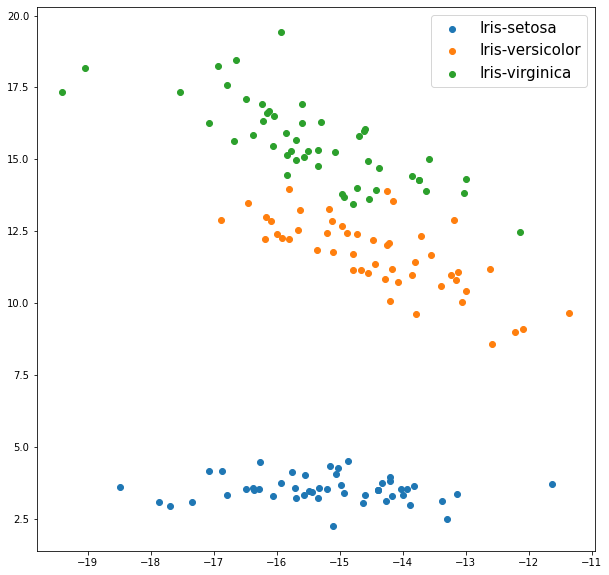

In [7]:
#project
X_red = v.T.dot(X)

# plot projected points
plt.figure(figsize=(10,10)) 
species = np.unique(y)

for i in range(len(species)):
    plt.scatter(X_red[0,y==species[i]],X_red[1,y==species[i]], label=species[i ])
    plt.legend(fontsize=15)

In [8]:
X_red.shape

(2, 150)